# Case 600: controlled VDI–Modelica crosswalk

This is the sole executable study notebook in `2_vdi`. It replaces broad sensitivity testing with a cumulative V1–V7 crosswalk. Every simulated case disables native VDI opaque/window short-wave paths and overwrites them with the same checked-in hourly `modelica_solar_gain_W` series. V1a/V1b are the deliberate decomposition pair: allocation changes at fixed IW topology, then topology changes at fixed all-AW allocation.

V7 is intentionally a provenance closure/no-op: the comparator's 0.414 ACH and floor convention were already retained, so equality with V6 is an executable assertion rather than an invented parameter change.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
HERE = Path.cwd().resolve()
if HERE.name != '2_vdi': HERE = HERE / '2_validation/_BESTEST/2_vdi'
sys.path.insert(0, str(HERE.parent/'validation/00_previous'))
import bestest_vdi_case600_crosswalk_engine as engine
pd.set_option('display.max_colwidth', 100)

## Source-allocation crosswalk

The Modelica/ISO fractions are calculated from the comparator parameters, not fitted to annual loads. Solar uses all three fractions; the 200 W internal gain uses 50% air at V6 and divides its radiant half between AW/IW in the same non-air proportions.

In [2]:
crosswalk = pd.DataFrame([
 {'source':'solar', 'f_air':engine.ISO_F_AIR, 'f_AW':engine.ISO_F_AW, 'f_IW':engine.ISO_F_IW},
 {'source':'internal gain', 'f_air':0.5, 'f_AW':0.5*engine.ISO_F_AW/(engine.ISO_F_AW+engine.ISO_F_IW), 'f_IW':0.5*engine.ISO_F_IW/(engine.ISO_F_AW+engine.ISO_F_IW)}])
assert np.allclose(crosswalk[['f_air','f_AW','f_IW']].sum(axis=1), 1.0)
display(crosswalk.round(6))

,source,f_air,f_AW,f_IW
0,solar,0.023822,0.151003,0.825175
1,internal gain,0.500000,0.077344,0.422656


## Run V0–V7

The rows are cumulative except the V1 decomposition pair. Heating/cooling HVAC remain 100% convective to match the Modelica air connector. Initialization and solver tuning are excluded by design.

In [3]:
summary, hourly = engine.run_all()
assert summary.annual_solar_MWh.nunique() == 1
assert np.isfinite(summary[['heating_MWh','cooling_MWh','maximum_balance_residual_W']]).all().all()
assert np.allclose(summary.loc[summary.scenario=='V6', ['heating_MWh','cooling_MWh']].to_numpy(), summary.loc[summary.scenario=='V7', ['heating_MWh','cooling_MWh']].to_numpy())
display(summary.round(5))

,scenario,interpretation,topology,construction_mode,solar_f_air,solar_f_AW,solar_f_IW,internal_f_air,inside_h_W_m2K,neutral_longwave,infiltration_ACH,annual_solar_MWh,heating_MWh,cooling_MWh,peak_heating_kW,peak_cooling_kW,maximum_balance_residual_W,compare_to,delta_heating_MWh,delta_cooling_MWh
0,V0,audited starting point: inferred 96 m² IW and area allocation,IW,layer-controlled,0.00000,NaN,NaN,1.0,8.0,False,0.414,12.11239,3.16027,2.99280,3.62325,4.24216,0.0,NaN,NaN,NaN
1,V1a,"allocation only: retain IW topology, send solar to AW",IW,layer-controlled,0.00000,1.00000,0.00000,1.0,8.0,False,0.414,12.11239,3.46688,3.20932,3.65506,4.52834,0.0,V0,0.30661,0.21652
2,V1b,"topology only relative to V1a: remove IW, retain all-AW solar",no-IW,layer-controlled,0.00000,1.00000,0.00000,1.0,8.0,False,0.414,12.11239,5.97015,4.46951,3.70670,4.65894,0.0,V1a,2.50328,1.26019
3,V2,matched Modelica solar-node fractions,IW,layer-controlled,0.02382,0.14741,0.82877,1.0,8.0,False,0.414,12.11239,2.83449,2.82664,3.58390,3.88249,0.0,V0,-0.32578,-0.16616
4,V3,U-value-controlled envelope reduction,IW,U-controlled,0.02382,0.14741,0.82877,1.0,8.0,False,0.414,12.11239,1.67123,1.89460,2.62614,2.51195,0.0,V2,-1.16326,-0.93204
5,V4,matched inside surface coefficient,IW,U-controlled,0.02382,0.14741,0.82877,1.0,9.1,False,0.414,12.11239,1.66134,1.98550,2.84873,2.86224,0.0,V3,-0.00989,0.09090
6,V5,harmonised long-wave boundary,IW,U-controlled,0.02382,0.14741,0.82877,1.0,9.1,True,0.414,12.11239,1.16832,2.39798,2.68540,3.01130,0.0,V4,-0.49302,0.41248
7,V6,matched 200 W internal-gain split,IW,U-controlled,0.02382,0.14741,0.82877,0.5,9.1,True,0.414,12.11239,1.17093,2.39508,2.68627,3.01051,0.0,V5,0.00261,-0.00290
8,V7,floor and airflow provenance resolved: comparator values retained,IW,U-controlled,0.02382,0.14741,0.82877,0.5,9.1,True,0.414,12.11239,1.17093,2.39508,2.68627,3.01051,0.0,V6,0.00000,0.00000


## One-change audit

This table is the methodological contract. V1a and V1b must be interpreted as contrasts against V0 and V1a respectively; V2 then restarts the cumulative Modelica-matching path with the IW topology retained.

In [4]:
audit = pd.DataFrame([
 ['V1a','V0','radiant receiving/source allocation'], ['V1b','V1a','thermal capacitance/topology'],
 ['V2','V0','explicit Modelica solar air/AW/IW fractions'], ['V3','V2','envelope convention: layer- to U-controlled'],
 ['V4','V3','inside total heat-transfer coefficient'], ['V5','V4','exterior long-wave convention'],
 ['V6','V5','internal-gain air/AW/IW split'], ['V7','V6','floor + airflow provenance; verified no-op']],
 columns=['scenario','compare_to','only interpretation changed'])
display(audit.merge(summary[['scenario','heating_MWh','cooling_MWh']], on='scenario').round(5))

,scenario,compare_to,only interpretation changed,heating_MWh,cooling_MWh
0,V1a,V0,radiant receiving/source allocation,3.46688,3.20932
1,V1b,V1a,thermal capacitance/topology,5.97015,4.46951
2,V2,V0,explicit Modelica solar air/AW/IW fractions,2.83449,2.82664
3,V3,V2,envelope convention: layer- to U-controlled,1.67123,1.89460
4,V4,V3,inside total heat-transfer coefficient,1.66134,1.98550
5,V5,V4,exterior long-wave convention,1.16832,2.39798
6,V6,V5,internal-gain air/AW/IW split,1.17093,2.39508
7,V7,V6,floor + airflow provenance; verified no-op,1.17093,2.39508


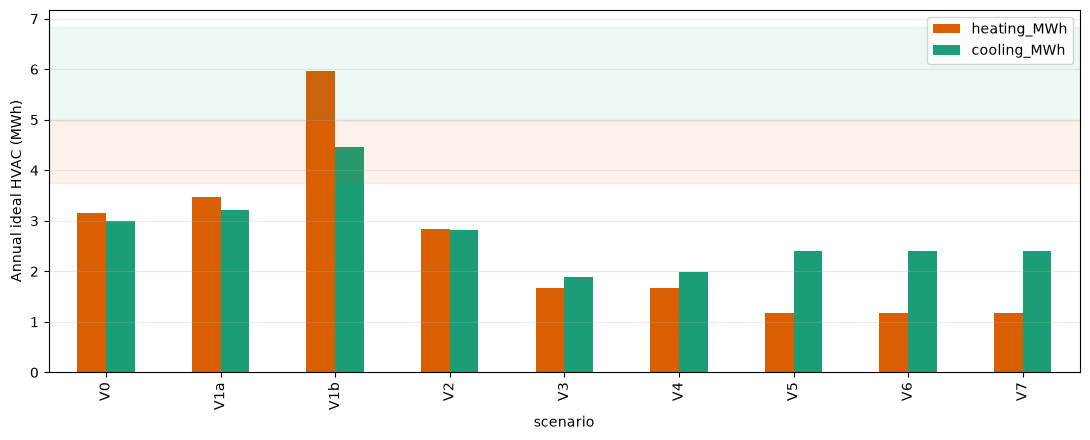

In [5]:
plot = summary.set_index('scenario')[['heating_MWh','cooling_MWh']]
ax = plot.plot.bar(figsize=(11,4.5), color=['#d95f02','#1b9e77'])
ax.axhspan(3.75,4.98,color='#d95f02',alpha=.08); ax.axhspan(5.00,6.83,color='#1b9e77',alpha=.08)
ax.set_ylabel('Annual ideal HVAC (MWh)'); ax.grid(axis='y',alpha=.25); plt.tight_layout(); plt.show()

## Interpretation and outputs

The output table reports absolute values and step deltas; do not select a setting because it enters the BESTEST band. The defensible result is the residual after the physical crosswalk. `results/2_vdi/case600_vdi_crosswalk/` contains the compact summary and full hourly trace. The hourly file repeats `modelica_solar_gain_W` for every scenario, making the overwrite auditable.

# Factorial combination check against BESTEST EUI bounds

This screening experiment reuses the existing crosswalk switches in a full $2^6$ design. It uses the same signed hourly Modelica solar vector in every run; native VDI solar remains disabled. Factor levels are discrete physical interpretations, not continuously tuned parameters. Results are assessed against the accepted EUI intervals, not their midpoints.

In [6]:
factorial, factor_levels, eui_bounds = engine.run_factorial()
expected_runs = int(np.prod([len(levels) for levels in factor_levels.values()]))
assert len(factorial) == expected_runs
assert factorial.annual_solar_MWh.nunique() == 1
assert np.isfinite(factorial[['heating_EUI','cooling_EUI','D_EUI','D_EUI_norm']]).all().all()
assert (factorial.loc[factorial.both_in_range, ['D_EUI','D_EUI_norm']] == 0).all().all()
n_both = int(factorial.both_in_range.sum())
pct_both = 100*n_both/len(factorial)
print(f'{n_both} of {len(factorial)} combinations ({pct_both:.1f}%) place both EUIs inside the BESTEST bounds.')
print('EUI bounds [kWh/m² yr]:', eui_bounds)

0 of 64 combinations (0.0%) place both EUIs inside the BESTEST bounds.
EUI bounds [kWh/m² yr]: {'heating': (78.125, 103.75), 'cooling': (104.16666666666667, 142.29166666666666)}


In [7]:
factor_columns = list(factor_levels)
display_columns = factor_columns + ['heating_EUI','cooling_EUI','heating_in_range','cooling_in_range','both_in_range','D_EUI','D_EUI_norm']
display(factorial[display_columns].round({'heating_EUI':2,'cooling_EUI':2,'D_EUI':3,'D_EUI_norm':4}))

,topology,source_allocation,envelope,inside_h,longwave,internal_gain,heating_EUI,cooling_EUI,heating_in_range,cooling_in_range,both_in_range,D_EUI,D_EUI_norm
0,no-IW,Modelica-fractions,layer-controlled,8.0,harmonised,Modelica-split,105.31,107.95,False,True,False,1.561,0.0609
1,no-IW,VDI-area,layer-controlled,8.0,harmonised,Modelica-split,105.45,106.44,False,True,False,1.698,0.0663
2,no-IW,Modelica-fractions,layer-controlled,9.1,harmonised,Modelica-split,109.24,123.32,False,True,False,5.489,0.2142
3,no-IW,VDI-area,layer-controlled,9.1,harmonised,Modelica-split,109.33,122.14,False,True,False,5.575,0.2176
4,no-IW,Modelica-fractions,layer-controlled,8.0,harmonised,all-air,113.15,102.43,False,False,False,9.555,0.3695
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,no-IW,VDI-area,U-controlled,9.1,harmonised,Modelica-split,31.00,36.54,False,False,False,82.427,2.5550
60,IW,VDI-area,U-controlled,8.0,harmonised,Modelica-split,26.06,45.01,False,False,False,78.805,2.5566
61,IW,Modelica-fractions,U-controlled,8.0,harmonised,Modelica-split,24.67,47.77,False,False,False,77.705,2.5573
62,IW,VDI-area,U-controlled,8.0,harmonised,all-air,26.00,45.08,False,False,False,78.797,2.5574


The first ranked row is labelled only as the **best-performing combination against the BESTEST EUI bounds**. It is not identified as correct or validated: factorial assumptions can compensate for one another. The complete compact table is saved to `results/2_vdi/case600_vdi_crosswalk/factorial_eui_summary.csv`.

# Paired solar-pipeline factorial comparison

The same stable F01–F64 physical combinations are evaluated twice. `modelica` disables native short-wave paths and injects the checked-in Modelica vector; `native_vdi` retains the standard VDI solar calculation and injects no Modelica solar. Solar treatment is an outer grouping variable, not a seventh factor.

In [8]:
dual, paired, dual_levels = engine.run_dual_solar_factorial()
assert len(dual) == 2*int(np.prod([len(x) for x in dual_levels.values()])) == 128
assert dual.groupby('factorial_id').size().eq(2).all()
assert dual.groupby('solar_group').annual_solar_MWh.nunique().eq(1).all()
assert np.isfinite(dual[['heating_MWh','cooling_MWh','D_MWh_norm']]).all().all()
assert (dual.loc[dual.both_in_range, 'D_MWh_norm'] == 0).all()
best = (dual.sort_values(['solar_group','both_in_range','D_MWh_norm'], ascending=[True,False,True]).groupby('solar_group', as_index=False).first())
passing = dual.groupby('solar_group').both_in_range.agg(['sum','count']).reset_index()
passing['percent_passing'] = 100*passing['sum']/passing['count']
best_table = best[['solar_group','factorial_id','heating_MWh','cooling_MWh','D_MWh_norm','both_in_range']].merge(passing, on='solar_group')
display(best_table.rename(columns={'sum':'number_passing','count':'total'}).round(4))

,solar_group,factorial_id,heating_MWh,cooling_MWh,D_MWh_norm,both_in_range,number_passing,total,percent_passing
0,modelica,F52,5.0549,5.1816,0.0609,False,0,64,0.000
1,native_vdi,F36,4.8234,5.6788,0.0000,True,2,64,3.125


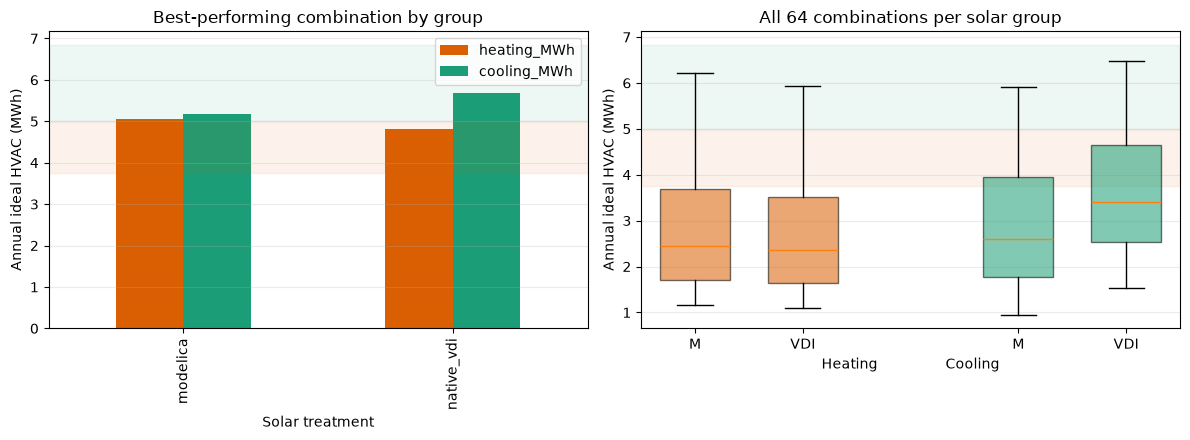

In [9]:
colors = ['#d95f02','#1b9e77']
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
best.set_index('solar_group')[['heating_MWh','cooling_MWh']].plot.bar(ax=axes[0], color=colors)
axes[0].axhspan(3.75,4.98,color=colors[0],alpha=.08); axes[0].axhspan(5.00,6.83,color=colors[1],alpha=.08)
axes[0].set_ylabel('Annual ideal HVAC (MWh)'); axes[0].set_xlabel('Solar treatment'); axes[0].grid(axis='y',alpha=.25); axes[0].set_title('Best-performing combination by group')
positions=[1,2,4,5]
data=[dual.loc[dual.solar_group=='modelica','heating_MWh'], dual.loc[dual.solar_group=='native_vdi','heating_MWh'], dual.loc[dual.solar_group=='modelica','cooling_MWh'], dual.loc[dual.solar_group=='native_vdi','cooling_MWh']]
bp=axes[1].boxplot(data,positions=positions,widths=.65,patch_artist=True,tick_labels=['M','VDI','M','VDI'])
for patch,color in zip(bp['boxes'],[colors[0],colors[0],colors[1],colors[1]]): patch.set_facecolor(color); patch.set_alpha(.55)
axes[1].axhspan(3.75,4.98,color=colors[0],alpha=.08); axes[1].axhspan(5.00,6.83,color=colors[1],alpha=.08)
axes[1].set_ylabel('Annual ideal HVAC (MWh)'); axes[1].set_xlabel('Heating                 Cooling'); axes[1].set_title('All 64 combinations per solar group'); axes[1].grid(axis='y',alpha=.25)
plt.tight_layout(); plt.show()

The displayed cases are only the **best-performing combinations against the BESTEST MWh bounds**, not correct or validated models. Paired deltas are saved with the two group summaries in `results/2_vdi/case600_vdi_crosswalk/`; they show whether the native-solar shift is systematic or dependent on the six physical choices.